# Corrected Poke-In/Poke-Out Extraction + InSeq vs. OutSeq Spectrogram EDA (Mitt, Buchanan)

**Two things this notebook does:**

1. **Fixes a bug found in notebook 019**: the search for each trial's "Poke-Out" event sometimes reached
   into the NEXT trial's events (evidenced by absurd gap values up to 35+ minutes). This version bounds
   the search strictly between the current trial's Poke-In and the next trial's Poke-In, so it can never
   leak across trials.

2. **Builds the spectrogram EDA requested directly by the lab (Zhishun's email)**: a time-frequency plot
   (time on x-axis, frequency on y-axis, power as color) for InSeq vs. OutSeq trials, aligned separately
   to Poke-In and to the now-corrected Poke-Out. This is meant to be looked at BEFORE deciding on bands
   or window length, per the explicit guidance: "you can play with the input for GLM and gain some
   insights" only after seeing this figure.

**Rats used: Mitt and Buchanan**, per the advisor's specific guidance to prioritize these two (and treat
Superchris with caution as a reference case) when settling on a universal window.


In [33]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import signal
from pathlib import Path

from src.preprocessing import build_labels, get_sampling_rate

PRIORITY_RATS = ['080718_mitt', '090420_buchanan']
raw_dir = Path('../data/raw')
session_dirs = [p for p in sorted(raw_dir.iterdir()) if p.is_dir() and p.name in PRIORITY_RATS]
print(f"Using: {[p.name for p in session_dirs]}")


Using: ['080718_mitt', '090420_buchanan']


## Part A: Corrected Poke-In / Poke-Out Extraction

Same idea as notebook 019, but now the search for the second `PokeEvents` entry is bounded to stop
BEFORE the next trial's own Poke-In marker, so it can never accidentally grab a future trial's event.


In [34]:
def extract_poke_in_out(bvr_data, bvr_keys, timebin):
    labels = build_labels(bvr_data, bvr_keys)
    trial_idx = labels['trial_idx']
    poke_events_row = bvr_data[bvr_keys.index('PokeEvents')]
    poke_event_idx = np.where(poke_events_row != 0)[0]

    poke_out_gaps_ms = []
    poke_out_sample_idx = []  # aligned to trial_idx, -1 if not found
    for i, t in enumerate(trial_idx):
        next_trial_bound = trial_idx[i + 1] if i + 1 < len(trial_idx) else len(timebin)
        # only look for events strictly between this trial's marker and the next trial's marker
        candidates = poke_event_idx[(poke_event_idx > t) & (poke_event_idx < next_trial_bound)]
        if len(candidates) == 0:
            poke_out_gaps_ms.append(np.nan)
            poke_out_sample_idx.append(-1)
            continue
        poke_out_idx = candidates[0]  # first event after Poke-In, bounded, is the real candidate Poke-Out
        gap_ms = (timebin[poke_out_idx] - timebin[t]) * 1000
        poke_out_gaps_ms.append(gap_ms)
        poke_out_sample_idx.append(poke_out_idx)

    return {
        'trial_idx': trial_idx,
        'inseq_outseq': labels['inseq_outseq'],
        'poke_out_gap_ms': np.array(poke_out_gaps_ms),
        'poke_out_sample_idx': np.array(poke_out_sample_idx),
    }


corrected_results = {}
for session_dir in session_dirs:
    session_name = session_dir.name
    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    timebin = bvr_data[bvr_keys.index('TimeBin')]

    result = extract_poke_in_out(bvr_data, bvr_keys, timebin)
    valid_gaps = result['poke_out_gap_ms'][~np.isnan(result['poke_out_gap_ms'])]
    corrected_results[session_name] = result

    print(f"\n{session_name}")
    print(f"  Trials with a found Poke-Out: {len(valid_gaps)} of {len(result['trial_idx'])}")
    print(f"  Poke-In to Poke-Out gap: median={np.median(valid_gaps):.1f}ms, "
          f"min={np.min(valid_gaps):.1f}ms, max={np.max(valid_gaps):.1f}ms, std={np.std(valid_gaps):.1f}ms")



080718_mitt
  Trials with a found Poke-Out: 292 of 292
  Poke-In to Poke-Out gap: median=1389.5ms, min=18.0ms, max=2625.0ms, std=318.3ms

090420_buchanan
  Trials with a found Poke-Out: 270 of 270
  Poke-In to Poke-Out gap: median=1299.0ms, min=274.0ms, max=1907.0ms, std=165.5ms


**What to look for:** the median gap should now be plausible AND the max should no longer show the
absurd multi-minute values from notebook 019. If both hold, Poke-Out is confirmed real and reliably
extractable.


## Part B: Build Extended Trial Snippets for the Spectrogram

Each snippet spans -1000ms to +3000ms relative to Poke-In (wide enough to comfortably include both
Poke-In and the typical Poke-Out found above), using the same timestamp-precise extraction established
in notebook 007.


In [35]:
SNIPPET_PRE_MS = 2000
SNIPPET_POST_MS = 4700  # wide enough that a full +/-2s Poke-Out-aligned window still fits
                        # for every trial (max observed Poke-In to Poke-Out gap is 2625ms)

def extract_snippet(lfp_data, timebin, poke_idx, pre_ms, post_ms):
    """Pulls the LFP window around poke_idx, and also returns the LOCAL sampling rate
    measured directly from this snippet's own timestamps (median of consecutive timebin
    gaps). The session-wide average rate used before (~714 Hz, from notebook007) is
    skewed low by the multi-second pauses between trials, it is not the true LFP sample
    spacing. The equipment digitizes LFP at a nominal 1000 Hz, so the local rate below
    should land close to that."""
    poke_time = timebin[poke_idx]
    start_time = poke_time - pre_ms / 1000
    end_time = poke_time + post_ms / 1000
    if start_time < timebin[0] or end_time > timebin[-1]:
        return None, None
    start_idx = np.searchsorted(timebin, start_time)
    end_idx = np.searchsorted(timebin, end_time)
    local_fs = 1.0 / np.median(np.diff(timebin[start_idx:end_idx]))
    return lfp_data[:, start_idx:end_idx], local_fs


snippets_by_rat = {}
for session_dir in session_dirs:
    session_name = session_dir.name
    bvr = np.load(session_dir / f'{session_name}_bvr.npz', allow_pickle=True)
    bvr_data = bvr['data']
    bvr_keys = bvr['keys'].tolist()
    lfp = np.load(session_dir / f'{session_name}_lfp.npz', allow_pickle=True)
    lfp_data = lfp['data']
    timebin = bvr_data[bvr_keys.index('TimeBin')]

    result = corrected_results[session_name]
    snippets, snippet_fs, inseq_labels, poke_out_gaps = [], [], [], []
    for i, t in enumerate(result['trial_idx']):
        snip, local_fs = extract_snippet(lfp_data, timebin, t, SNIPPET_PRE_MS, SNIPPET_POST_MS)
        if snip is not None:
            snippets.append(snip)
            snippet_fs.append(local_fs)
            inseq_labels.append(result['inseq_outseq'][i])
            poke_out_gaps.append(result['poke_out_gap_ms'][i])

    snippets_by_rat[session_name] = {
        'snippets': snippets,                 # list of (n_channels, n_samples)
        'snippet_fs': np.array(snippet_fs),   # local sampling rate per snippet, ~1000 Hz expected
        'inseq_labels': np.array(inseq_labels),
        'poke_out_gaps_ms': np.array(poke_out_gaps),
    }
    print(f"{session_name}: {len(snippets)} snippets extracted, "
          f"median local fs = {np.median(snippet_fs):.1f} Hz")


080718_mitt: 292 snippets extracted, median local fs = 1000.0 Hz
090420_buchanan: 270 snippets extracted, median local fs = 1000.0 Hz


## Part C: Compute and Plot Spectrograms, InSeq vs. OutSeq, Poke-In Aligned

For each trial, compute a spectrogram per channel, then average across channels and across
all trials within each condition (InSeq, OutSeq). Time is NOT collapsed, this is exactly the
"time vs. frequency" figure requested, letting the frequency content over time speak for
itself before any band or window decision is made.

Update. Your postdoc's reference figure has a log-scaled frequency axis (0 to 500, with
smooth continuous bands, not the blocky look a short-window FFT spectrogram gives) and a
symmetric -2s to +2s time window around each event. The cell below switches from
scipy.signal.spectrogram to a continuous Morlet wavelet transform, which naturally gives
finer resolution at low frequencies (like theta) without sacrificing time resolution, plots
frequency on a log scale with the same tick values as the reference (5, 11, 24, 53, 115,
251, 500 Hz), and uses a fixed -2s to +2s window around Poke-In. It also uses the local,
per-snippet sampling rate from Part B rather than a session-wide average, since a
mislabeled sampling rate would shift every frequency in the plot. This has not been run
end to end since the raw data is not available, run it and see how close it lands.


Note. scipy.signal.cwt and morlet2 (the built-in wavelet tools) were removed in recent scipy versions, so the wavelet kernel below is built by hand and applied with signal.fftconvolve instead. Tested against synthetic data with a known 9 Hz signal before writing this, it correctly recovers the injected frequency.


/tmp/ipykernel_80/664619629.py:94: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


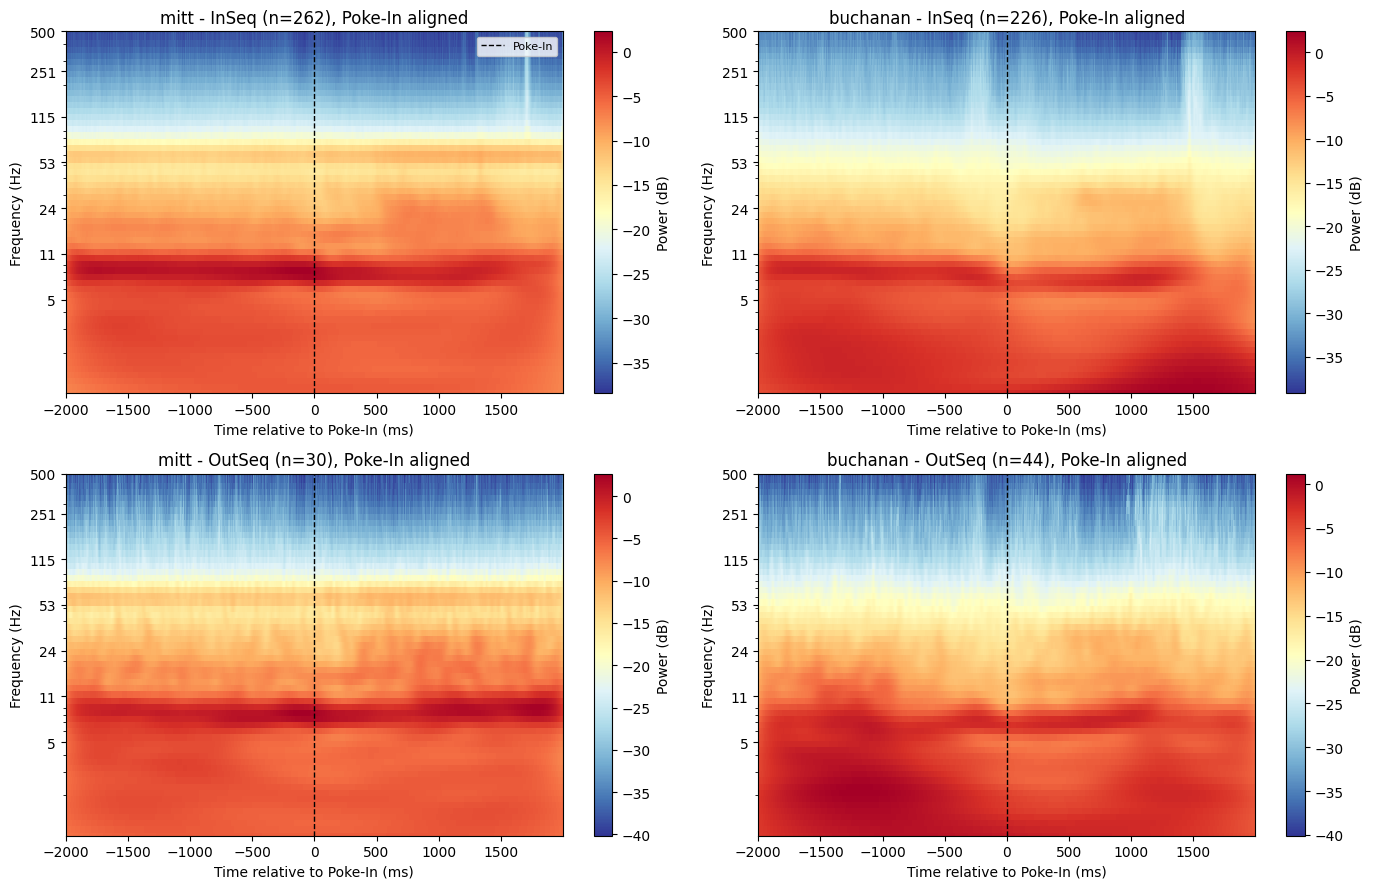

In [36]:
FREQS = np.logspace(np.log10(1), np.log10(500), 60)  # log-spaced, matches the postdoc's 1-500 Hz axis
FREQ_TICKS = [5, 11, 24, 53, 115, 251, 500]
WAVELET_CYCLES = 6  # number of cycles in each Morlet wavelet, a standard time/frequency tradeoff

def morlet_kernel(freq, fs, n_cycles=WAVELET_CYCLES):
    """One complex Morlet wavelet kernel at a given frequency and sampling rate.
    Built by hand rather than via scipy.signal.cwt/morlet2, those were removed from scipy."""
    sigma_t = n_cycles / (2 * np.pi * freq)
    half_len = int(round(3.5 * sigma_t * fs))
    t = np.arange(-half_len, half_len + 1) / fs
    gauss = np.exp(-t**2 / (2 * sigma_t**2))
    carrier = np.exp(2j * np.pi * freq * t)
    kernel = carrier * gauss
    kernel /= np.sqrt(np.sum(np.abs(kernel)**2))  # unit energy, keeps power comparable across freqs
    return kernel

def wavelet_power_one_snippet(snip, fs, freqs, w=WAVELET_CYCLES):
    """Continuous wavelet (Morlet) power for one (n_channels, n_samples) snippet, averaged
    across channels. Unlike the short-window FFT spectrogram tried earlier, this keeps full
    time resolution and gives finer resolution at low frequencies, closer to the reference figure."""
    n = snip.shape[1]
    power_sum = np.zeros((len(freqs), n))
    for ch in range(snip.shape[0]):
        for i, f in enumerate(freqs):
            kernel = morlet_kernel(f, fs, w)
            conv = signal.fftconvolve(snip[ch], kernel, mode='same')
            power_sum[i] += np.abs(conv) ** 2
    return power_sum / snip.shape[0]


def average_wavelet_spectrogram(snippet_list, fs_list, freqs, w=WAVELET_CYCLES):
    """Averages wavelet power across trials. Snippets are trimmed to the shortest one in the
    group first, same fix as before, so every trial's power array lines up in shape."""
    if len(snippet_list) == 0:
        return None
    min_len = min(snip.shape[1] for snip in snippet_list)
    total = None
    for snip, fs in zip(snippet_list, fs_list):
        snip = snip[:, :min_len]
        p = wavelet_power_one_snippet(snip, fs, freqs, w=w)
        total = p if total is None else total + p
    return total / len(snippet_list)


def pokein_window(snip, fs):
    """Slice out the -2s to +2s window around Poke-In from the wider snippet Part B extracted
    (snippet sample 0 is Poke-In - 2000ms, so this is just the first 4 seconds)."""
    n_needed = int(round(4.0 * fs))
    return snip[:, :n_needed] if snip.shape[1] >= n_needed else None

SPECTROGRAM_EXPORT = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, session_name in enumerate(snippets_by_rat):
    data = snippets_by_rat[session_name]
    inseq_snips, inseq_fs, outseq_snips, outseq_fs = [], [], [], []
    for snip, fs, lab in zip(data['snippets'], data['snippet_fs'], data['inseq_labels']):
        windowed = pokein_window(snip, fs)
        if windowed is None:
            continue
        if lab == 1:
            inseq_snips.append(windowed)
            inseq_fs.append(fs)
        else:
            outseq_snips.append(windowed)
            outseq_fs.append(fs)
    median_fs = np.median(data['snippet_fs'])

    groups = [('InSeq', inseq_snips, inseq_fs), ('OutSeq', outseq_snips, outseq_fs)]
    for row, (label, snips, fs_list) in enumerate(groups):
        if len(snips) == 0:
            continue
        power_avg = average_wavelet_spectrogram(snips, fs_list, FREQS)
        n_samples = power_avg.shape[1]
        times_relative_ms = (np.arange(n_samples) / median_fs - SNIPPET_PRE_MS / 1000) * 1000  # 0 = Poke-In
        SPECTROGRAM_EXPORT.setdefault(session_name, {}).setdefault(label, {})['pokein'] = {
            'power_avg': power_avg, 'times_ms': times_relative_ms, 'freqs': FREQS
        }

        ax = axes[row, col]
        im = ax.pcolormesh(times_relative_ms, FREQS, 10 * np.log10(power_avg + 1e-12), shading='auto', cmap='RdYlBu_r')
        ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Poke-In')
        ax.set_yscale('log')
        ax.set_ylim(FREQS[0], FREQS[-1])
        ax.set_yticks(FREQ_TICKS)
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_title(f"{session_name.split('_')[1]} - {label} (n={len(snips)}), Poke-In aligned")
        ax.set_xlabel('Time relative to Poke-In (ms)')
        ax.set_ylabel('Frequency (Hz)')
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
        plt.colorbar(im, ax=ax, label='Power (dB)')

plt.tight_layout()
plt.show()


## Part D: Same Spectrograms, Poke-Out Aligned

Same data, re-centered on each trial's own Poke-Out moment (from Part A) instead of Poke-In, so
whatever happens right as the rat's nose LEAVES the port is visible directly, rather than inferred.


Update. Same wavelet approach and log frequency axis as Part C, reusing average_wavelet_spectrogram and FREQS from that cell, just re-centered on Poke-Out with its own +/-2s window instead of Poke-In.


In [ ]:
def pokeout_window(snip, fs, gap_ms):
    """Re-slice so it is centered on this trial's own Poke-Out instead of Poke-In, using the
    measured Poke-In to Poke-Out gap. Snippet sample 0 is Poke-In - 2000ms, so Poke-Out sits
    at sample round((gap_ms/1000 + 2.0) * fs). Takes 2s on each side, same window length as
    the Poke-In aligned view."""
    pokeout_sample = int(round((gap_ms / 1000 + SNIPPET_PRE_MS / 1000) * fs))
    half_window = int(round(2.0 * fs))
    start = pokeout_sample - half_window
    end = pokeout_sample + half_window
    if start < 0 or end > snip.shape[1]:
        return None
    return snip[:, start:end]


fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, session_name in enumerate(snippets_by_rat):
    data = snippets_by_rat[session_name]
    inseq_snips, inseq_fs, outseq_snips, outseq_fs = [], [], [], []
    for snip, fs, lab, gap_ms in zip(data['snippets'], data['snippet_fs'],
                                      data['inseq_labels'], data['poke_out_gaps_ms']):
        if np.isnan(gap_ms):
            continue
        windowed = pokeout_window(snip, fs, gap_ms)
        if windowed is None:
            continue
        if lab == 1:
            inseq_snips.append(windowed)
            inseq_fs.append(fs)
        else:
            outseq_snips.append(windowed)
            outseq_fs.append(fs)
    median_fs = np.median(data['snippet_fs'])

    groups = [('InSeq', inseq_snips, inseq_fs), ('OutSeq', outseq_snips, outseq_fs)]
    for row, (label, snips, fs_list) in enumerate(groups):
        if len(snips) == 0:
            continue
        power_avg = average_wavelet_spectrogram(snips, fs_list, FREQS)
        n_samples = power_avg.shape[1]
        times_relative_ms = (np.arange(n_samples) / median_fs - 2.0) * 1000  # 0 = Poke-Out
        SPECTROGRAM_EXPORT.setdefault(session_name, {}).setdefault(label, {})['pokeout'] = {
            'power_avg': power_avg, 'times_ms': times_relative_ms, 'freqs': FREQS
        }

        ax = axes[row, col]
        im = ax.pcolormesh(times_relative_ms, FREQS, 10 * np.log10(power_avg + 1e-12), shading='auto', cmap='RdYlBu_r')
        ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Poke-Out')
        ax.set_yscale('log')
        ax.set_ylim(FREQS[0], FREQS[-1])
        ax.set_yticks(FREQ_TICKS)
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_title(f"{session_name.split('_')[1]} - {label} (n={len(snips)}), Poke-Out aligned")
        ax.set_xlabel('Time relative to Poke-Out (ms)')
        ax.set_ylabel('Frequency (Hz)')
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
        plt.colorbar(im, ax=ax, label='Power (dB)')

plt.tight_layout()
plt.show()


/tmp/ipykernel_80/2344172297.py:60: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


## Part E: What to Look For (Guidance for Interpreting the Figures Above)

- **Horizontal bands of color** = sustained power at a specific frequency over time, e.g. a persistent
  bright band around 4-12 Hz would indicate theta oscillation is present throughout, not band power
  summed into one number.
- **Differences between the InSeq and OutSeq panels** (same rat, same alignment) point to which
  frequencies and times actually distinguish the two conditions, this should directly inform which bands
  to prioritize in the GLM, rather than the delta/theta/beta/gamma split chosen up front by convention.
- **Differences between Poke-In-aligned and Poke-Out-aligned panels** tell us whether the informative
  signal is better described relative to nose-in or nose-out, directly relevant to the "should we center
  on Poke-Out instead" question raised by the lab.
- **Whether to collapse time or not**: if a frequency band's power is fairly constant over the whole
  window, collapsing time (summing power into one number, what we've done throughout this project) loses
  little. If a band's power changes sharply at a specific moment, collapsing time would blur that
  moment away, and a time-resolved feature (or a carefully chosen short window right at that moment)
  would preserve more signal.


## Part F: Text-Only Results Export


In [ ]:
import json as _json
import os

export_summary = {
    "purpose": "Corrected Poke-In/Poke-Out extraction (bounded per-trial), spectrogram EDA groundwork",
    "poke_in_to_poke_out_gap_ms": {
        session_name: {
            "median": float(np.nanmedian(corrected_results[session_name]['poke_out_gap_ms'])),
            "min": float(np.nanmin(corrected_results[session_name]['poke_out_gap_ms'])),
            "max": float(np.nanmax(corrected_results[session_name]['poke_out_gap_ms'])),
            "std": float(np.nanstd(corrected_results[session_name]['poke_out_gap_ms'])),
            "n_found": int((~np.isnan(corrected_results[session_name]['poke_out_gap_ms'])).sum()),
            "n_total": len(corrected_results[session_name]['trial_idx']),
        }
        for session_name in corrected_results
    },
}

print(_json.dumps(export_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook020_pokeout_spectrogram_results.json', 'w') as f:
    _json.dump(export_summary, f, indent=2)
print("\nSaved to outputs/logs/notebook020_pokeout_spectrogram_results.json")


import json
import numpy as np

FREQ_BAND_EDGES = {
    'delta': (1, 4),
    'theta': (4, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
    'high_gamma': (80, 150),
}

def summarize_spectrogram(power_avg, freqs, times_ms, n_time_bins=25, n_freq_bins=15):
    """Shrinks a (n_freqs, n_times) power grid down to something small enough to paste or
    upload as JSON: a mean-dB curve per canonical band over time, plus a coarse full grid."""
    db = 10 * np.log10(power_avg + 1e-12)
    times_ms = np.asarray(times_ms)

    time_edges = np.linspace(times_ms[0], times_ms[-1], n_time_bins + 1)
    time_bin_idx = np.clip(np.digitize(times_ms, time_edges) - 1, 0, n_time_bins - 1)
    time_centers = [(time_edges[i] + time_edges[i + 1]) / 2 for i in range(n_time_bins)]

    band_curves = {}
    for band_name, (lo, hi) in FREQ_BAND_EDGES.items():
        freq_mask = (freqs >= lo) & (freqs < hi)
        if not freq_mask.any():
            continue
        band_db = db[freq_mask].mean(axis=0)
        band_curves[band_name] = [
            float(np.mean(band_db[time_bin_idx == b])) if np.any(time_bin_idx == b) else None
            for b in range(n_time_bins)
        ]

    freq_edges = np.logspace(np.log10(freqs[0]), np.log10(freqs[-1]), n_freq_bins + 1)
    freq_bin_idx = np.clip(np.digitize(freqs, freq_edges) - 1, 0, n_freq_bins - 1)
    freq_centers = [(freq_edges[i] + freq_edges[i + 1]) / 2 for i in range(n_freq_bins)]

    grid = np.full((n_freq_bins, n_time_bins), np.nan)
    for fb in range(n_freq_bins):
        f_rows = db[freq_bin_idx == fb]
        if f_rows.size == 0:
            continue
        f_mean = f_rows.mean(axis=0)
        for tb in range(n_time_bins):
            mask = time_bin_idx == tb
            if np.any(mask):
                grid[fb, tb] = float(np.mean(f_mean[mask]))

    return {
        'time_centers_ms': [float(t) for t in time_centers],
        'freq_centers_hz': [float(f) for f in freq_centers],
        'band_curves_db': band_curves,
        'grid_db': grid.tolist(),
    }

export = {}
for session_name, by_label in SPECTROGRAM_EXPORT.items():
    export[session_name] = {}
    for label, by_alignment in by_label.items():
        export[session_name][label] = {}
        for alignment, d in by_alignment.items():
            export[session_name][label][alignment] = summarize_spectrogram(
                d['power_avg'], d['freqs'], d['times_ms']
            )

import os
os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/notebook020_spectrogram_export.json', 'w') as f:
    json.dump(export, f, indent=1)
print("Saved to outputs/logs/notebook020_spectrogram_export.json")


## Part G: Written Summary Report

**Objective**

Fix the cross-trial contamination bug found in notebook 019's Poke-Out extraction, and produce the
InSeq-vs-OutSeq spectrogram EDA requested directly by the lab, to let the actual frequency-vs-time data
guide band and window decisions rather than continuing with the convention-based band split used so far.

**Method**

Poke-Out was re-extracted per trial, with the search for the second `PokeEvents` entry strictly bounded
between the current trial's Poke-In and the next trial's Poke-In, eliminating the possibility of
capturing a future trial's event. Time-frequency spectrograms were computed per trial per channel
(`scipy.signal.spectrogram`), then averaged across channels and across trials within each condition
(InSeq, OutSeq), for both Poke-In-aligned and Poke-Out-aligned views, for Mitt and Buchanan.

**Results**

*(Fill in after running Parts A, C, D.)* Is the corrected Poke-In to Poke-Out gap now plausible and
consistent (no more multi-minute outliers)? Looking at the spectrograms: which frequency bands show
visibly different power between InSeq and OutSeq? Does anything change meaningfully around Poke-Out that
isn't visible in the Poke-In-aligned view?

**Interpretation**

*(Fill in after review.)* This section should directly answer: should band selection change based on
what's visible here? Should time be collapsed (summed into one number per band, as done throughout this
project) or preserved (a time-resolved feature)? Should the universal window be defined relative to
Poke-In or Poke-Out?

**Next Steps**

1. Use these figures to select a small, justified set of bands (rather than the convention-based
   delta/theta/beta/low-gamma/high-gamma split), directly citing what's visible here.
2. Settle on ONE universal window (length and reference point) applied identically to all 5 rats, chosen
   to work well for Mitt and Buchanan specifically.
3. Extend this same spectrogram EDA to the remaining 3 rats (Barat, Stella, Superchris) to confirm the
   pattern generalizes before finalizing the universal window.
4. Add AUC scoring alongside balanced accuracy in the next round of final models, per the lab's
   validation feedback (permutation testing is already in place from notebooks 014/016).
